# Exploración del Dataset arXiv Metadata
Fuente: `arxiv-metadata-oai-snapshot.json` (Kaggle / arXiv OAI snapshot)  
Formato: JSON Lines (un objeto JSON por línea)

## 0. Configuración

In [3]:
# ─── Parámetros configurables ─────────────────────────────────────────────────
DATASET_PATH   = r'C:\Users\AaronMCC\Documents\arxiv_cs_dataset_exploration\dataset\arxiv-metadata-oai-snapshot.json'
SAMPLE_SIZE    = None # 200_000   # registros a cargar para exploración rápida (None = todo)
CS_OUTPUT_PATH = r'C:\Users\AaronMCC\Documents\arxiv_cs_dataset_exploration\dataset\arxiv_cs.parquet'
RANDOM_SEED    = 42
# ──────────────────────────────────────────────────────────────────────────────

import json
import re
from collections import Counter
from itertools import islice

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option("display.max_colwidth", 80)
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid", palette="muted")
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 1. Carga del Dataset

In [4]:
def load_arxiv(path, n=None):
    """Carga el JSON Lines en un DataFrame. Si n es int, toma solo n líneas."""
    records = []
    with open(path, "r", encoding="utf-8") as f:
        source = islice(f, n) if n else f
        for line in source:
            records.append(json.loads(line))
    return pd.DataFrame(records)

print(f"Cargando {'todo el dataset' if SAMPLE_SIZE is None else f'{SAMPLE_SIZE:,} registros'}...")
df = load_arxiv(DATASET_PATH, SAMPLE_SIZE)
print(f"Registros cargados: {len(df):,}")
df.head(3)

Cargando todo el dataset...
Registros cargados: 2,982,054


,id,submitter,authors,title,comments,journal-ref,doi,report-no,categories,license,abstract,versions,update_date,authors_parsed
0,0704.0001,Pavel Nadolsky,"C. Bal\'azs, E. L. Berger, P. M. Nadolsky, C.-P. Yuan",Calculation of prompt diphoton production cross sections at Tevatron and\n ...,"37 pages, 15 figures; published version","Phys.Rev.D76:013009,2007",10.1103/PhysRevD.76.013009,ANL-HEP-PR-07-12,hep-ph,None,A fully differential calculation in perturbative quantum chromodynamics is...,"[{'version': 'v1', 'created': 'Mon, 2 Apr 2007 19:18:42 GMT'}, {'version': '...",2008-11-26,"[[Balázs, C., ], [Berger, E. L., ], [Nadolsky, P. M., ], [Yuan, C. -P., ]]"
1,0704.0002,Louis Theran,Ileana Streinu and Louis Theran,Sparsity-certifying Graph Decompositions,To appear in Graphs and Combinatorics,None,None,None,math.CO cs.CG,http://arxiv.org/licenses/nonexclusive-distrib/1.0/,"We describe a new algorithm, the $(k,\ell)$-pebble game with colors, and u...","[{'version': 'v1', 'created': 'Sat, 31 Mar 2007 02:26:18 GMT'}, {'version': ...",2008-12-13,"[[Streinu, Ileana, ], [Theran, Louis, ]]"
2,0704.0003,Hongjun Pan,Hongjun Pan,The evolution of the Earth-Moon system based on the dark matter field\n flu...,"23 pages, 3 figures",None,None,None,physics.gen-ph,None,The evolution of Earth-Moon system is described by the dark matter field\n...,"[{'version': 'v1', 'created': 'Sun, 1 Apr 2007 20:46:54 GMT'}, {'version': '...",2008-01-13,"[[Pan, Hongjun, ]]"


## 2. Exploración General

In [5]:
print("=== Shape ===")
print(f"{df.shape[0]:,} filas  ×  {df.shape[1]} columnas\n")

print("=== Columnas ===")
print(df.dtypes.to_string(), "\n")

print("=== Valores nulos ===")
nulls = df.isnull().sum()
print(nulls[nulls > 0].to_string() if nulls.any() else "Sin valores nulos")

=== Shape ===
2,982,054 filas  ×  14 columnas

=== Columnas ===
id                object
submitter         object
authors           object
title             object
comments          object
journal-ref       object
doi               object
report-no         object
categories        object
license           object
abstract          object
versions          object
update_date       object
authors_parsed    object 

=== Valores nulos ===
submitter        15185
comments        814949
journal-ref    2045980
doi            1685663
report-no      2792092
license         452752


In [6]:
# Muestra representativa de registros completos
df.sample(3, random_state=RANDOM_SEED)[
    ["id", "title", "categories", "update_date", "authors"]
]

,id,title,categories,update_date,authors
1790678,2302.05744,Rethinking Vision Transformer and Masked Autoencoder in Multimodal Face\n A...,cs.CV,2023-02-14,"Zitong Yu, Rizhao Cai, Yawen Cui, Xin Liu, Yongjian Hu, Alex Kot"
92487,0811.1135,Isospin mixing of isospin-projected Slater determinants: formalism and\n pr...,nucl-th,2009-05-29,"M. Rafalski, W. Satula, J. Dobaczewski"
2423472,2509.18292,Fully Distributed State Estimation for Multi-agent Systems and its Applicati...,eess.SY cs.SY,2025-09-24,"Shuaiting Huang, Haodong Jiang, Chengcheng Zhao, Peng Cheng, Junfeng Wu"


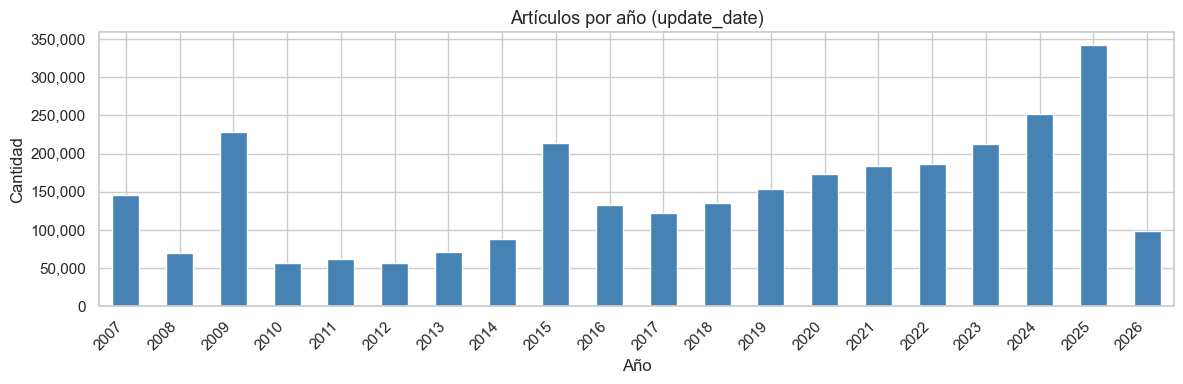

In [7]:
# Distribución temporal: artículos por año
df["year"] = pd.to_datetime(df["update_date"], errors="coerce").dt.year

fig, ax = plt.subplots(figsize=(12, 4))
year_counts = df["year"].value_counts().sort_index()
year_counts.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Artículos por año (update_date)", fontsize=13)
ax.set_xlabel("Año")
ax.set_ylabel("Cantidad")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 3. Análisis de Categorías

In [8]:
# Cada artículo puede tener múltiples categorías separadas por espacios
# Explotamos para obtener una fila por (artículo, categoría)
df["cat_list"] = df["categories"].str.strip().str.split()

df_cats = df.explode("cat_list").rename(columns={"cat_list": "category"})
df_cats = df_cats[df_cats["category"].notna() & (df_cats["category"] != "")]

print(f"Total (artículo, categoría) pares: {len(df_cats):,}")
print(f"Categorías únicas            : {df_cats['category'].nunique():,}")

Total (artículo, categoría) pares: 5,142,681
Categorías únicas            : 176


In [9]:
# Extraemos el prefijo de área (e.g. 'cs', 'math', 'physics')
df_cats["prefix"] = df_cats["category"].str.extract(r"^([a-zA-Z\-]+)", expand=False).str.lower()

# Mapeo de prefijos a nombre legible
PREFIX_LABELS = {
    "cs"       : "Computer Science",
    "math"     : "Mathematics",
    "physics"  : "Physics",
    "astro-ph" : "Astrophysics",
    "cond-mat" : "Condensed Matter",
    "hep-ph"   : "High Energy Physics – Phenomenology",
    "hep-th"   : "High Energy Physics – Theory",
    "hep-ex"   : "High Energy Physics – Experiment",
    "hep-lat"  : "High Energy Physics – Lattice",
    "gr-qc"    : "General Relativity & Quantum Cosmology",
    "quant-ph" : "Quantum Physics",
    "nlin"     : "Nonlinear Sciences",
    "nucl-th"  : "Nuclear Theory",
    "nucl-ex"  : "Nuclear Experiment",
    "stat"     : "Statistics",
    "eess"     : "Electrical Engineering & Signal Processing",
    "econ"     : "Economics",
    "q-bio"    : "Quantitative Biology",
    "q-fin"    : "Quantitative Finance",
}

df_cats["area"] = df_cats["prefix"].map(PREFIX_LABELS).fillna(df_cats["prefix"])

area_counts = df_cats.groupby("area")["id"].nunique().sort_values(ascending=False)
print("Top 20 áreas por número de artículos únicos:")
print(area_counts.head(20).to_string())

Top 20 áreas por número de artículos únicos:
area
Computer Science                              892992
Mathematics                                   742278
Condensed Matter                              413653
Astrophysics                                  380020
Physics                                       299669
High Energy Physics – Phenomenology           194395
High Energy Physics – Theory                  180618
Quantum Physics                               175668
Statistics                                    142343
Electrical Engineering & Signal Processing    120696
General Relativity & Quantum Cosmology        120089
math-ph                                        88633
Nuclear Theory                                 61896
High Energy Physics – Experiment               59453
Quantitative Biology                           54145
Nonlinear Sciences                             46398
High Energy Physics – Lattice                  30076
Nuclear Experiment                             28

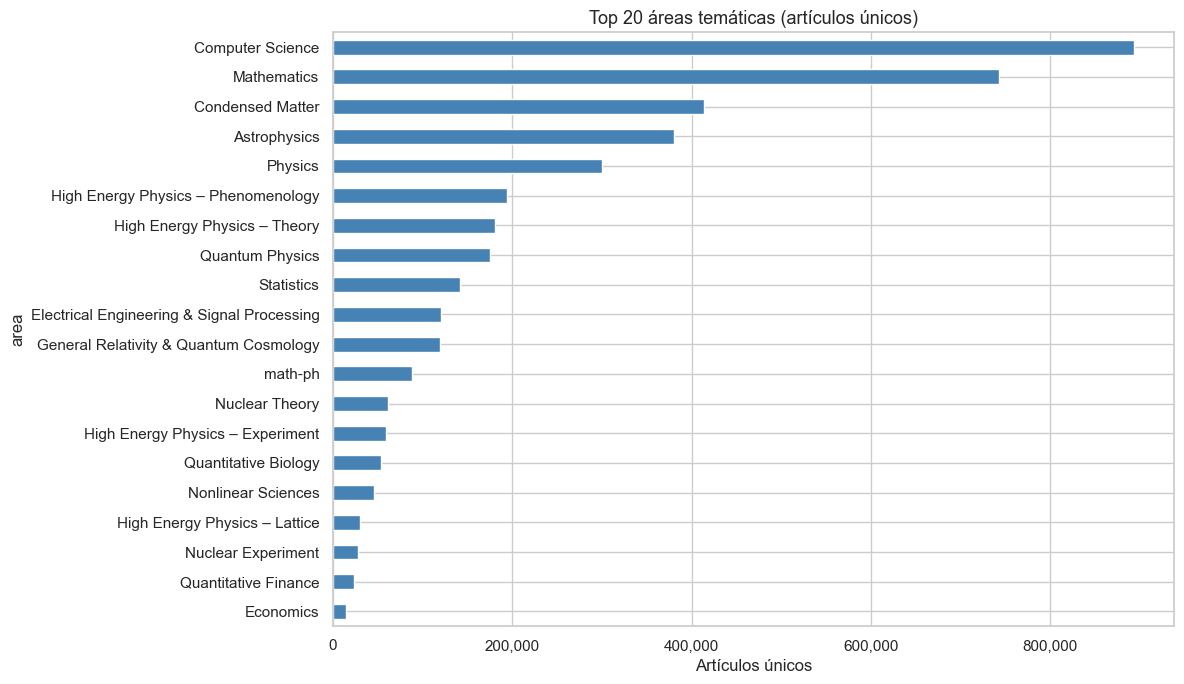

In [10]:
fig, ax = plt.subplots(figsize=(12, 7))
top_areas = area_counts.head(20)
top_areas[::-1].plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Top 20 áreas temáticas (artículos únicos)", fontsize=13)
ax.set_xlabel("Artículos únicos")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

## 4. Ciencias de la Computación (cs.*)

In [11]:
# Subcategorías cs.*
CS_SUBLABELS = {
    "cs.AI"  : "Artificial Intelligence",
    "cs.AR"  : "Hardware Architecture",
    "cs.CC"  : "Computational Complexity",
    "cs.CE"  : "Computational Engineering",
    "cs.CG"  : "Computational Geometry",
    "cs.CL"  : "Computation & Language (NLP)",
    "cs.CR"  : "Cryptography & Security",
    "cs.CV"  : "Computer Vision",
    "cs.CY"  : "Computers & Society",
    "cs.DB"  : "Databases",
    "cs.DC"  : "Distributed & Parallel Computing",
    "cs.DL"  : "Digital Libraries",
    "cs.DM"  : "Discrete Mathematics",
    "cs.DS"  : "Data Structures & Algorithms",
    "cs.ET"  : "Emerging Technologies",
    "cs.FL"  : "Formal Languages & Automata",
    "cs.GL"  : "General Literature",
    "cs.GR"  : "Graphics",
    "cs.GT"  : "Game Theory",
    "cs.HC"  : "Human-Computer Interaction",
    "cs.IR"  : "Information Retrieval",
    "cs.IT"  : "Information Theory",
    "cs.LG"  : "Machine Learning",
    "cs.LO"  : "Logic in CS",
    "cs.MA"  : "Multiagent Systems",
    "cs.MM"  : "Multimedia",
    "cs.MS"  : "Mathematical Software",
    "cs.NA"  : "Numerical Analysis",
    "cs.NE"  : "Neural & Evolutionary Computing",
    "cs.NI"  : "Networking & Internet Architecture",
    "cs.OH"  : "Other CS",
    "cs.OS"  : "Operating Systems",
    "cs.PF"  : "Performance",
    "cs.PL"  : "Programming Languages",
    "cs.RO"  : "Robotics",
    "cs.SC"  : "Symbolic Computation",
    "cs.SD"  : "Sound",
    "cs.SE"  : "Software Engineering",
    "cs.SI"  : "Social & Information Networks",
    "cs.SY"  : "Systems & Control",
}

cs_mask = df_cats["prefix"] == "cs"
df_cs_cats = df_cats[cs_mask].copy()
df_cs_cats["cs_label"] = df_cs_cats["category"].str.upper().map(CS_SUBLABELS).fillna(df_cs_cats["category"])

cs_sub_counts = df_cs_cats.groupby(["category", "cs_label"])["id"].nunique() \
                           .sort_values(ascending=False).reset_index()
cs_sub_counts.columns = ["Categoría", "Descripción", "Artículos únicos"]
print(f"Subcategorías cs.* encontradas: {len(cs_sub_counts)}")
cs_sub_counts

Subcategorías cs.* encontradas: 40


,Categoría,Descripción,Artículos únicos
0,cs.LG,cs.LG,257067
1,cs.CV,cs.CV,184612
2,cs.AI,cs.AI,166910
3,cs.CL,cs.CL,104104
4,cs.IT,cs.IT,53429
5,cs.RO,cs.RO,50543
6,cs.CR,cs.CR,46353
7,cs.SY,cs.SY,43769
8,cs.NA,cs.NA,33202
9,cs.HC,cs.HC,28878


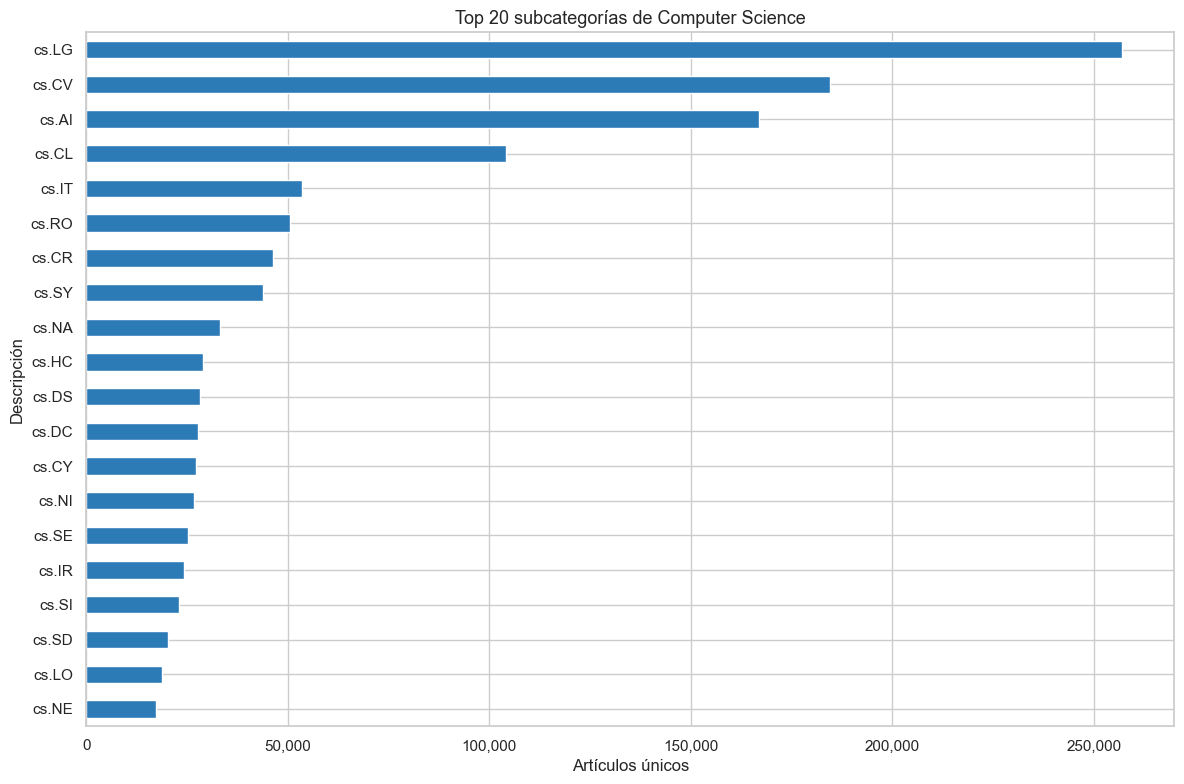

In [12]:
top_cs = cs_sub_counts.head(20).set_index("Descripción")["Artículos únicos"]

fig, ax = plt.subplots(figsize=(12, 8))
top_cs[::-1].plot(kind="barh", ax=ax, color="#2c7bb6", edgecolor="white")
ax.set_title("Top 20 subcategorías de Computer Science", fontsize=13)
ax.set_xlabel("Artículos únicos")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

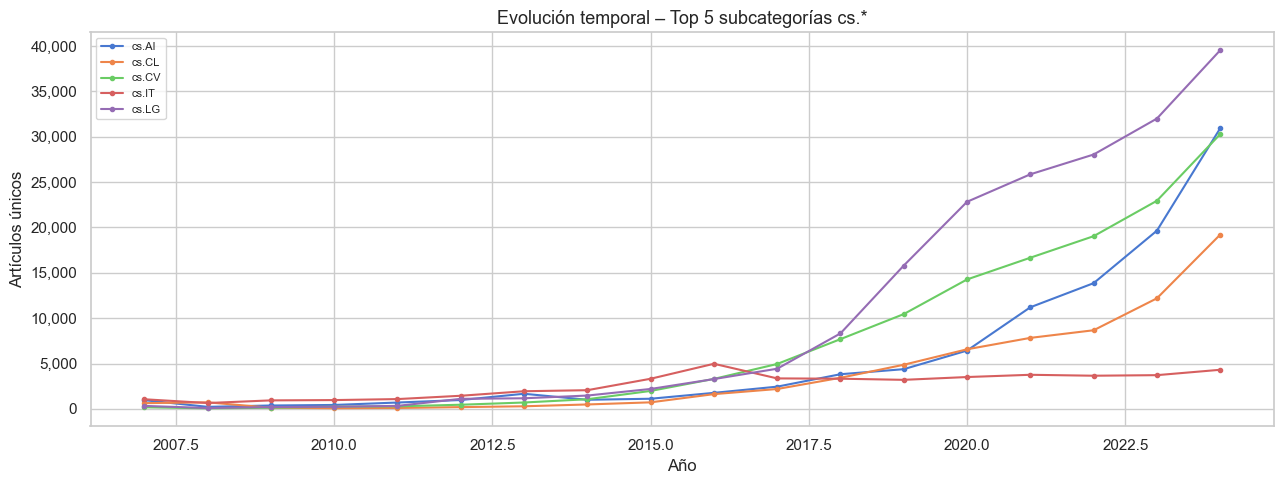

In [13]:
# Evolución temporal de las 5 subcategorías cs.* más frecuentes
top5_cs = cs_sub_counts.head(5)["Categoría"].tolist()

df_cs_trend = df_cs_cats[df_cs_cats["category"].isin(top5_cs)].copy()
df_cs_trend["year"] = pd.to_datetime(df_cs_trend["update_date"], errors="coerce").dt.year
trend = df_cs_trend.groupby(["year", "cs_label"])["id"].nunique().reset_index()
trend.columns = ["year", "Subcategoría", "artículos"]
trend = trend[trend["year"].between(2000, 2024)]

fig, ax = plt.subplots(figsize=(13, 5))
for label, grp in trend.groupby("Subcategoría"):
    ax.plot(grp["year"], grp["artículos"], marker="o", markersize=3, label=label)
ax.set_title("Evolución temporal – Top 5 subcategorías cs.*", fontsize=13)
ax.set_xlabel("Año")
ax.set_ylabel("Artículos únicos")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 5. Ciencias Exactas (math, physics, stat, quant-ph, …)

In [14]:
EXACT_PREFIXES = {
    "math"     : "Mathematics",
    "physics"  : "Physics (general)",
    "astro-ph" : "Astrophysics",
    "cond-mat" : "Condensed Matter",
    "hep-ph"   : "HEP – Phenomenology",
    "hep-th"   : "HEP – Theory",
    "hep-ex"   : "HEP – Experiment",
    "hep-lat"  : "HEP – Lattice",
    "gr-qc"    : "General Relativity & Quantum Cosmology",
    "quant-ph" : "Quantum Physics",
    "nucl-th"  : "Nuclear Theory",
    "nucl-ex"  : "Nuclear Experiment",
    "nlin"     : "Nonlinear Sciences",
    "stat"     : "Statistics",
}

exact_mask = df_cats["prefix"].isin(EXACT_PREFIXES)
df_exact = df_cats[exact_mask].copy()
df_exact["area_label"] = df_exact["prefix"].map(EXACT_PREFIXES)

exact_area = df_exact.groupby("area_label")["id"].nunique().sort_values(ascending=False)
print("Artículos únicos por área (ciencias exactas):")
print(exact_area.to_string())

Artículos únicos por área (ciencias exactas):
area_label
Mathematics                               742278
Condensed Matter                          413653
Astrophysics                              380020
Physics (general)                         299669
HEP – Phenomenology                       194395
HEP – Theory                              180618
Quantum Physics                           175668
Statistics                                142343
General Relativity & Quantum Cosmology    120089
Nuclear Theory                             61896
HEP – Experiment                           59453
Nonlinear Sciences                         46398
HEP – Lattice                              30076
Nuclear Experiment                         28190


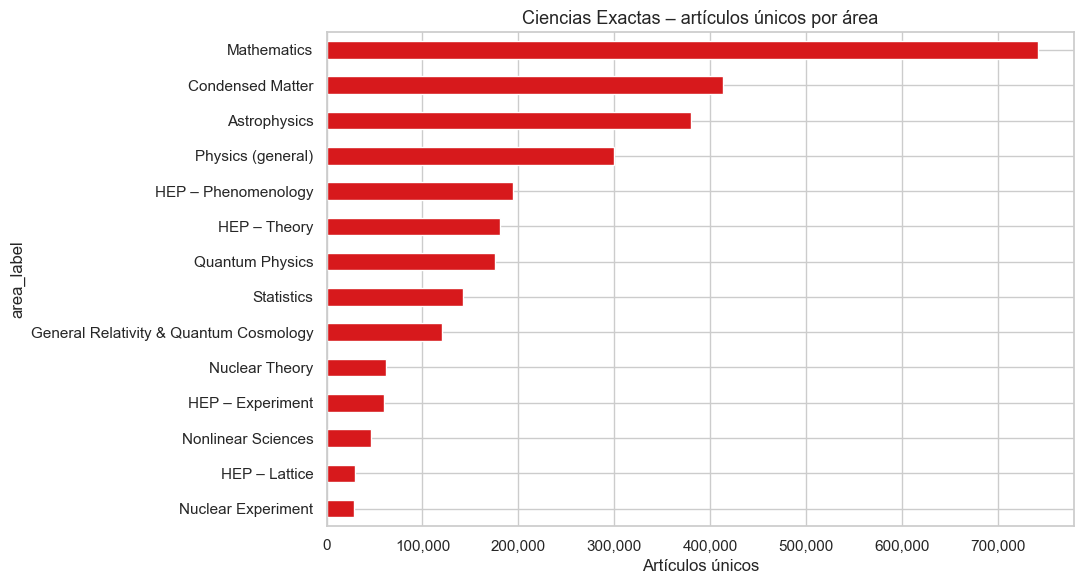

In [15]:
fig, ax = plt.subplots(figsize=(11, 6))
exact_area[::-1].plot(kind="barh", ax=ax, color="#d7191c", edgecolor="white")
ax.set_title("Ciencias Exactas – artículos únicos por área", fontsize=13)
ax.set_xlabel("Artículos únicos")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

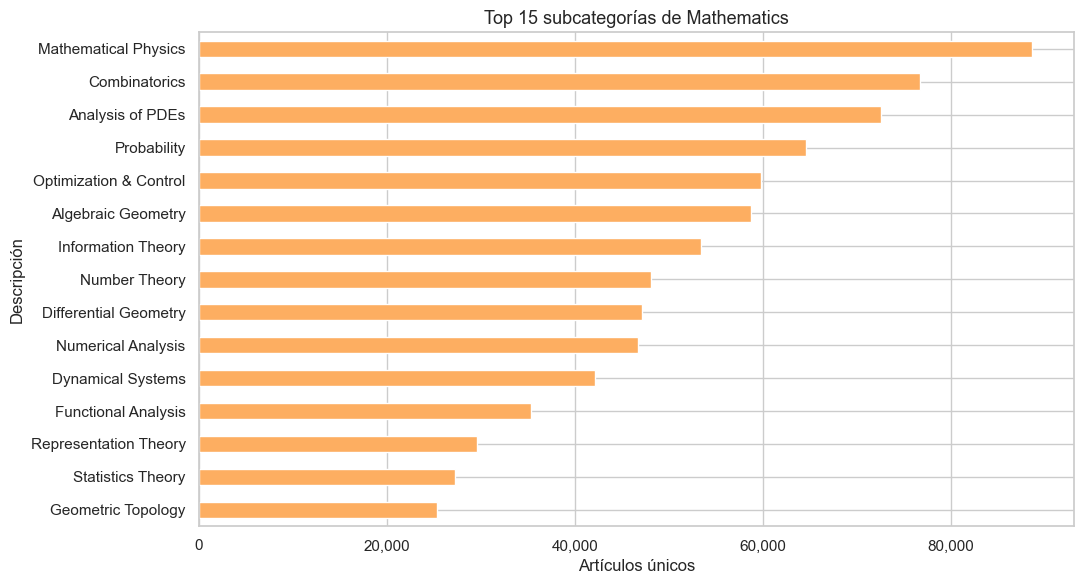

In [16]:
# Detalle: subcategorías de math.*
MATH_SUBLABELS = {
    "math.AC":"Commutative Algebra", "math.AG":"Algebraic Geometry",
    "math.AP":"Analysis of PDEs",   "math.AT":"Algebraic Topology",
    "math.CA":"Classical Analysis",  "math.CO":"Combinatorics",
    "math.CT":"Category Theory",     "math.CV":"Complex Variables",
    "math.DG":"Differential Geometry","math.DS":"Dynamical Systems",
    "math.FA":"Functional Analysis", "math.GM":"General Mathematics",
    "math.GN":"General Topology",    "math.GR":"Group Theory",
    "math.GT":"Geometric Topology",  "math.HO":"History & Overview",
    "math.IT":"Information Theory",  "math.KT":"K-Theory & Homology",
    "math.LO":"Logic",               "math.MG":"Metric Geometry",
    "math.MP":"Mathematical Physics","math.NA":"Numerical Analysis",
    "math.NT":"Number Theory",        "math.OA":"Operator Algebras",
    "math.OC":"Optimization & Control","math.PR":"Probability",
    "math.QA":"Quantum Algebra",     "math.RA":"Rings & Algebras",
    "math.RT":"Representation Theory","math.SG":"Symplectic Geometry",
    "math.SP":"Spectral Theory",     "math.ST":"Statistics Theory",
}

math_mask = df_cats["prefix"] == "math"
df_math_cats = df_cats[math_mask].copy()
df_math_cats["math_label"] = df_math_cats["category"].map(MATH_SUBLABELS).fillna(df_math_cats["category"])

math_sub = df_math_cats.groupby(["category", "math_label"])["id"].nunique() \
                        .sort_values(ascending=False).reset_index()
math_sub.columns = ["Categoría", "Descripción", "Artículos únicos"]

top_math = math_sub.head(15).set_index("Descripción")["Artículos únicos"]
fig, ax = plt.subplots(figsize=(11, 6))
top_math[::-1].plot(kind="barh", ax=ax, color="#fdae61", edgecolor="white")
ax.set_title("Top 15 subcategorías de Mathematics", fontsize=13)
ax.set_xlabel("Artículos únicos")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

C:\Users\AaronMCC\AppData\Local\Temp\ipykernel_5516\3998696501.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  n_exact = df[df["categories"].str.contains(


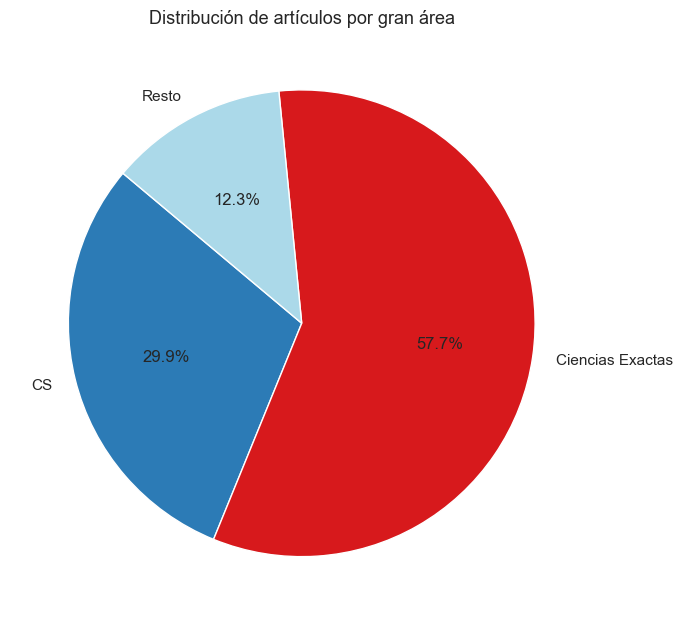

CS            : 892,992 artículos únicos
Ciencias Exactas: 1,721,472 artículos únicos
Total dataset : 2,982,028


In [17]:
# Comparativa: CS vs Exact Sciences (proporción de artículos)
n_cs    = df[df["categories"].str.contains(r"\bcs\.", na=False)]["id"].nunique()
n_exact = df[df["categories"].str.contains(
    r"\b(math|physics|astro-ph|cond-mat|hep-|gr-qc|quant-ph|nucl-|nlin|stat)\.",
    na=False, regex=True)]["id"].nunique()
n_total = df["id"].nunique()

labels = ["CS", "Ciencias Exactas", "Resto"]
sizes  = [n_cs, n_exact, max(0, n_total - n_cs - n_exact)]

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(sizes, labels=labels, autopct="%1.1f%%",
       colors=["#2c7bb6", "#d7191c", "#abd9e9"], startangle=140)
ax.set_title("Distribución de artículos por gran área", fontsize=13)
plt.tight_layout()
plt.show()

print(f"CS            : {n_cs:,} artículos únicos")
print(f"Ciencias Exactas: {n_exact:,} artículos únicos")
print(f"Total dataset : {n_total:,}")

## 6. Separación del Subconjunto de Computer Science

In [18]:
# Un artículo se incluye si al menos una de sus categorías pertenece a cs.*
cs_ids = df[df["categories"].str.contains(r"(?:^|\s)cs\.", na=False, regex=True)]["id"]
df_cs = df[df["id"].isin(cs_ids)].copy()

print(f"Artículos en subconjunto CS : {len(df_cs):,}")
print(f"Proporción del total cargado: {len(df_cs)/len(df)*100:.1f}%")
df_cs.head(3)[["id", "title", "categories", "update_date"]]

Artículos en subconjunto CS : 892,992
Proporción del total cargado: 29.9%


,id,title,categories,update_date
1,0704.0002,Sparsity-certifying Graph Decompositions,math.CO cs.CG,2008-12-13
45,0704.0046,A limit relation for entropy and channel capacity per unit cost,quant-ph cs.IT math.IT,2009-11-13
46,0704.0047,Intelligent location of simultaneously active acoustic emission sources:\n ...,cs.NE cs.AI,2009-09-29


In [19]:
# Columna auxiliar: lista limpia de categorías cs.* del artículo
def get_cs_cats(cat_str):
    if pd.isna(cat_str):
        return []
    return [c for c in cat_str.split() if c.lower().startswith("cs.")]

df_cs["cs_categories"] = df_cs["categories"].apply(get_cs_cats)
df_cs["cs_primary"]    = df_cs["cs_categories"].apply(lambda x: x[0] if x else None)

print("Distribución por categoría cs.* primaria:")
primary_dist = df_cs["cs_primary"].value_counts()
primary_dist.head(15)

Distribución por categoría cs.* primaria:


cs_primary
cs.LG    163515
cs.CV    158670
cs.CL     80665
cs.IT     46983
cs.AI     46299
cs.RO     38704
cs.CR     33652
cs.SY     26912
cs.NA     26775
cs.DS     19902
cs.NI     19793
cs.SE     19694
cs.HC     18482
cs.DC     18018
cs.CY     15732
Name: count, dtype: int64

In [20]:
# Guardar como Parquet (eficiente para análisis posteriores)
df_cs.to_parquet(CS_OUTPUT_PATH, index=False)
print(f"Subconjunto CS guardado en: {CS_OUTPUT_PATH}")
print(f"Tamaño final: {df_cs.shape}")

Subconjunto CS guardado en: C:\Users\AaronMCC\Documents\arxiv_cs_dataset_exploration\dataset\arxiv_cs.parquet
Tamaño final: (892992, 18)


In [21]:
# Verificación de lectura
df_cs_check = pd.read_parquet(CS_OUTPUT_PATH)
print("Lectura verificada:", df_cs_check.shape)
df_cs_check.dtypes

Lectura verificada: (892992, 18)


id                object
submitter         object
authors           object
title             object
comments          object
journal-ref       object
doi               object
report-no         object
categories        object
license           object
abstract          object
versions          object
update_date       object
authors_parsed    object
year               int32
cat_list          object
cs_categories     object
cs_primary        object
dtype: object

---
## Resumen

| Paso | Resultado |
|------|-----------|
| Dataset cargado | `df` |
| Categorías expandidas | `df_cats` |
| Solo CS | `df_cs` → guardado en `arxiv_cs.parquet` |
| Ciencias Exactas | `df_exact` (en memoria) |

> Para cargar el subconjunto CS en otra sesión:  
> `df_cs = pd.read_parquet('arxiv_cs.parquet')`